In [2]:
library(googledrive)
drive_auth(use_oob = TRUE, cache = FALSE)

dir.create("data", showWarnings = FALSE)

fetch_and_unzip <- function(drive_path, out_subdir) {
  zip_path <- file.path("data", basename(drive_path))
  drive_download(drive_path, path = zip_path, overwrite = TRUE)
  out_dir <- file.path("data", out_subdir)
  dir.create(out_dir, showWarnings = FALSE)
  unzip(zip_path, exdir = out_dir)
  out_dir
}

# whatever you actually have in ds_proj right now:
# dsb_path     <- fetch_and_unzip("ds_proj/stage1_train.zip", "dsb2018_test")
monusac_path <- fetch_and_unzip("ds_proj/MoNuSAC_images_and_annotations.zip", "monusac")

Please point your browser to the following url: 

https://accounts.google.com/o/oauth2/v2/auth?client_id=603366585132-frjlouoa3s2ono25d2l9ukvhlsrlnr7k.apps.googleusercontent.com&scope=https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email&redirect_uri=https%3A%2F%2Fwww.tidyverse.org%2Fgoogle-callback%2F&response_type=code&state=eafd06d15260cc9f6a270d1ae3de9b11&access_type=offline&prompt=consent



Enter authorization code: eyJjb2RlIjoiNC8wQVRzTVpxQjhuc2lWalRPU3NMamlMU2tScWFLN3kyZzNMNUkyT3BhZ0pLbFVSSXBpanc5ZzM1enRseTkzUnhPUVJYaFRBUSIsInN0YXRlIjoiZWFmZDA2ZDE1MjYwY2M5ZjZhMjcwZDFhZTNkZTliMTEifQ==


File downloaded:

• MoNuSAC_images_and_annotations.zip <id: 1uubRY152wCWPY85Eik8c3VJtKHajoBZq>

Saved locally as:

• data/MoNuSAC_images_and_annotations.zip



In [3]:
install.packages(c("tidyverse", "xml2", "R.matlab", "gt", "googledrive"))
if (!requireNamespace("BiocManager", quietly = TRUE)) install.packages("BiocManager")
BiocManager::install("EBImage", update = FALSE, ask = FALSE)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘V8’, ‘litedown’, ‘reactR’, ‘R.methodsS3’, ‘R.oo’, ‘R.utils’, ‘bigD’, ‘bitops’, ‘juicyjuice’, ‘markdown’, ‘reactable’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.1 (2026-06-24)

Installing package(s) 'BiocVersion', 'EBImage'

also installing the dependencies ‘BiocGenerics’, ‘abind’, ‘tiff’, ‘jpeg’, ‘png’, ‘locfit’, ‘fftwtools’, ‘RCurl’


Warning message in install.packages(...):
“installation of package ‘fftwtools’ had non-zero exit status”
Warning message in install.packages(...):
“installation of package ‘EBImage’ had non-zero exit status”


In [6]:
# list.files(dsb_path, recursive = FALSE) |> head(10)
list.files(monusac_path, recursive = TRUE) |> head(40)

[1] "MoNuSAC_images_and_annotations/TCGA-55-1594-01Z-00-DX1/TCGA-55-1594-01Z-00-DX1_001.svs"
 [2] "MoNuSAC_images_and_annotations/TCGA-55-1594-01Z-00-DX1/TCGA-55-1594-01Z-00-DX1_001.tif"
 [3] "MoNuSAC_images_and_annotations/TCGA-55-1594-01Z-00-DX1/TCGA-55-1594-01Z-00-DX1_001.xml"
 [4] "MoNuSAC_images_and_annotations/TCGA-55-1594-01Z-00-DX1/TCGA-55-1594-01Z-00-DX1_002.svs"
 [5] "MoNuSAC_images_and_annotations/TCGA-55-1594-01Z-00-DX1/TCGA-55-1594-01Z-00-DX1_002.tif"
 [6] "MoNuSAC_images_and_annotations/TCGA-55-1594-01Z-00-DX1/TCGA-55-1594-01Z-00-DX1_002.xml"
 [7] "MoNuSAC_images_and_annotations/TCGA-55-1594-01Z-00-DX1/TCGA-55-1594-01Z-00-DX1_003.svs"
 [8] "MoNuSAC_images_and_annotations/TCGA-55-1594-01Z-00-DX1/TCGA-55-1594-01Z-00-DX1_003.tif"
 [9] "MoNuSAC_images_and_annotations/TCGA-55-1594-01Z-00-DX1/TCGA-55-1594-01Z-00-DX1_003.xml"
[10] "MoNuSAC_images_and_annotations/TCGA-55-1594-01Z-00-DX1/TCGA-55-1594-01Z-00-DX1_004.svs"
[11] "MoNuSAC_images_and_annotations/TCGA-55-1594-01Z-00-DX1/TCGA-55-1594-01Z-00-DX1_004.tif"
[12] "MoNuSAC_images_and_annotations/TCGA-55-1594-01Z-00-DX1/TCGA-55-1594-01Z-00-DX1_004.xml"
[13] "MoNuSAC_images_and_annotations/TCGA-55-1594-01Z-00-DX1/TCGA-55-1594-01Z-00-DX1_005.svs"
[14] "MoNuSAC_images_and_annotations/TCGA-55-1594-01Z-00-DX1/TCGA-55-1594-01Z-00-DX1_005.tif"
[15] "MoNuSAC_images_and_annotations/TCGA-55-1594-01Z-00-DX1/TCGA-55-1594-01Z-00-DX1_005.xml"
[16] "MoNuSAC_images_and_annotations/TCGA-5P-A9K0-01Z-00-DX1/TCGA-5P-A9K0-01Z-00-DX1_1.svs"  
[17] "MoNuSAC_images_and_annotations/TCGA-5P-A9K0-01Z-00-DX1/TCGA-5P-A9K0-01Z-00-DX1_1.tif"  
[18] "MoNuSAC_images_and_annotations/TCGA-5P-A9K0-01Z-00-DX1/TCGA-5P-A9K0-01Z-00-DX1_1.xml"  
[19] "MoNuSAC_images_and_annotations/TCGA-5P-A9K0-01Z-00-DX1/TCGA-5P-A9K0-01Z-00-DX1_2.svs"  
[20] "MoNuSAC_images_and_annotations/TCGA-5P-A9K0-01Z-00-DX1/TCGA-5P-A9K0-01Z-00-DX1_2.tif"  
[21] "MoNuSAC_images_and_annotations/TCGA-5P-A9K0-01Z-00-DX1/TCGA-5P-A9K0-01Z-00-DX1_2.xml"  
[22] "MoNuSAC_images_and_annotations/TCGA-5P-A9K0-01Z-00-DX1/TCGA-5P-A9K0-01Z-00-DX1_3.svs"  
[23] "MoNuSAC_images_and_annotations/TCGA-5P-A9K0-01Z-00-DX1/TCGA-5P-A9K0-01Z-00-DX1_3.tif"  
[24] "MoNuSAC_images_and_annotations/TCGA-5P-A9K0-01Z-00-DX1/TCGA-5P-A9K0-01Z-00-DX1_3.xml"  
[25] "MoNuSAC_images_and_annotations/TCGA-69-7760-01Z-00-DX1/TCGA-69-7760-01Z-00-DX1_001.svs"
[26] "MoNuSAC_images_and_annotations/TCGA-69-7760-01Z-00-DX1/TCGA-69-7760-01Z-00-DX1_001.tif"
[27] "MoNuSAC_images_and_annotations/TCGA-69-7760-01Z-00-DX1/TCGA-69-7760-01Z-00-DX1_001.xml"
[28] "MoNuSAC_images_and_annotations/TCGA-69-7760-01Z-00-DX1/TCGA-69-7760-01Z-00-DX1_002.svs"
[29] "MoNuSAC_images_and_annotations/TCGA-69-7760-01Z-00-DX1/TCGA-69-7760-01Z-00-DX1_002.tif"
[30] "MoNuSAC_images_and_annotations/TCGA-69-7760-01Z-00-DX1/TCGA-69-7760-01Z-00-DX1_002.xml"
[31] "MoNuSAC_images_and_annotations/TCGA-69-7760-01Z-00-DX1/TCGA-69-7760-01Z-00-DX1_003.svs"
[32] "MoNuSAC_images_and_annotations/TCGA-69-7760-01Z-00-DX1/TCGA-69-7760-01Z-00-DX1_003.tif"
[33] "MoNuSAC_images_and_annotations/TCGA-69-7760-01Z-00-DX1/TCGA-69-7760-01Z-00-DX1_003.xml"
[34] "MoNuSAC_images_and_annotations/TCGA-69-7760-01Z-00-DX1/TCGA-69-7760-01Z-00-DX1_004.svs"
[35] "MoNuSAC_images_and_annotations/TCGA-69-7760-01Z-00-DX1/TCGA-69-7760-01Z-00-DX1_004.tif"
[36] "MoNuSAC_images_and_annotations/TCGA-69-7760-01Z-00-DX1/TCGA-69-7760-01Z-00-DX1_004.xml"
[37] "MoNuSAC_images_and_annotations/TCGA-69-A59K-01Z-00-DX1/TCGA-69-A59K-01Z-00-DX1_001.svs"
[38] "MoNuSAC_images_and_annotations/TCGA-69-A59K-01Z-00-DX1/TCGA-69-A59K-01Z-00-DX1_001.tif"
[39] "MoNuSAC_images_and_annotations/TCGA-69-A59K-01Z-00-DX1/TCGA-69-A59K-01Z-00-DX1_001.xml"
[40] "MoNuSAC_images_and_annotations/TCGA-69-A59K-01Z-00-DX1/TCGA-69-A59K-01Z-00-DX1_002.svs"

In [8]:
system("apt-get update -y")
system("apt-get install -y libfftw3-dev libtiff5-dev libjpeg-dev libpng-dev")

install.packages("fftwtools")
BiocManager::install("EBImage", update = FALSE, ask = FALSE)

library(EBImage)  # should load cleanly now

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.1 (2026-06-24)

Installing package(s) 'EBImage'


Attaching package: ‘EBImage’


The following object is masked from ‘package:purrr’:

    transpose




In [10]:
suppressPackageStartupMessages({
  library(tidyverse); library(EBImage); library(xml2); library(gt)
})

TARGET_SIZE <- 512L

safe_warn <- function(msg) warning(msg, call. = FALSE, immediate. = TRUE)

resize_label_mask_nn <- function(mask, out_w, out_h) {
  in_h <- nrow(mask); in_w <- ncol(mask)
  row_idx <- pmin(in_h, pmax(1, round(seq(1, in_h, length.out = out_h))))
  col_idx <- pmin(in_w, pmax(1, round(seq(1, in_w, length.out = out_w))))
  mask[row_idx, col_idx, drop = FALSE]
}

nucleus_stats_from_labelmask <- function(label_mask) {
  ids <- sort(unique(as.vector(label_mask))); ids <- ids[ids != 0]
  if (length(ids) == 0) {
    return(tibble(nucleus_id = integer(0), area_px = numeric(0),
                   centroid_x = numeric(0), centroid_y = numeric(0),
                   bbox_xmin = numeric(0), bbox_ymin = numeric(0),
                   bbox_xmax = numeric(0), bbox_ymax = numeric(0),
                   aspect_ratio = numeric(0)))
  }
  map_dfr(ids, function(id) {
    idx <- which(label_mask == id, arr.ind = TRUE)
    ys <- idx[, 1]; xs <- idx[, 2]
    w <- max(xs) - min(xs) + 1; h <- max(ys) - min(ys) + 1
    tibble(nucleus_id = id, area_px = length(xs),
           centroid_x = mean(xs), centroid_y = mean(ys),
           bbox_xmin = min(xs), bbox_ymin = min(ys),
           bbox_xmax = max(xs), bbox_ymax = max(ys),
           aspect_ratio = max(w, h) / max(1, min(w, h)))
  })
}

# ---------------- DSB2018 ----------------
list_image_ids_dsb2018 <- function(base_path) {
  dirs <- list.dirs(base_path, full.names = FALSE, recursive = FALSE)
  dirs[dirs != ""]
}

load_one_dsb2018 <- function(base_path, image_id) {
  img_dir <- file.path(base_path, image_id, "images")
  mask_dir <- file.path(base_path, image_id, "masks")
  img_files <- list.files(img_dir, full.names = TRUE)
  if (length(img_files) == 0) { safe_warn(sprintf("[DSB2018] no image for '%s'", image_id)); return(NULL) }
  img <- tryCatch(EBImage::readImage(img_files[1]), error = function(e) NULL)
  if (is.null(img)) { safe_warn(sprintf("[DSB2018] unreadable image '%s'", image_id)); return(NULL) }
  mask_files <- list.files(mask_dir, full.names = TRUE)
  if (length(mask_files) == 0) { safe_warn(sprintf("[DSB2018] no masks for '%s'", image_id)); return(NULL) }

  orig_h <- dim(img)[2]; orig_w <- dim(img)[1]
  label_mask <- matrix(0L, nrow = orig_h, ncol = orig_w)
  for (i in seq_along(mask_files)) {
    m <- tryCatch(EBImage::readImage(mask_files[i]), error = function(e) NULL)
    if (is.null(m)) { safe_warn(sprintf("[DSB2018] bad mask in '%s'", image_id)); next }
    m_bin <- t(as.matrix(m) > 0.5)
    label_mask[m_bin & label_mask == 0] <- i
  }
  list(image_id = image_id, image = img, label_mask = label_mask,
       orig_w = orig_w, orig_h = orig_h, class_lookup = NULL)
}

# ---------------- MoNuSAC ----------------
find_image_file <- function(base_path, image_id) {
  for (ext in c(".tif", ".tiff", ".png", ".jpg", ".jpeg", ".svs")) {
    cand <- file.path(base_path, paste0(image_id, ext))
    if (file.exists(cand)) return(cand)
  }
  NA_character_
}

polygon_to_mask <- function(xs, ys, w, h) {
  m <- matrix(FALSE, nrow = h, ncol = w); n <- length(xs)
  if (n < 3) return(m)
  ymin <- max(1, floor(min(ys))); ymax <- min(h, ceiling(max(ys)))
  for (row in ymin:ymax) {
    y <- row; xints <- c()
    for (k in seq_len(n)) {
      x1 <- xs[k]; y1 <- ys[k]; x2 <- xs[(k %% n) + 1]; y2 <- ys[(k %% n) + 1]
      if ((y1 <= y && y2 > y) || (y2 <= y && y1 > y))
        xints <- c(xints, x1 + (y - y1) / (y2 - y1) * (x2 - x1))
    }
    if (length(xints) >= 2) {
      xints <- sort(xints)
      for (p in seq(1, length(xints) - 1, by = 2)) {
        xa <- max(1, round(xints[p])); xb <- min(w, round(xints[p + 1]))
        if (xa <= xb) m[row, xa:xb] <- TRUE
      }
    }
  }
  m
}

# Recursively finds every subfolder that has at least one .xml — that's a
# per-patient/organ folder in the official MoNuSAC layout.
list_image_ids_monusac <- function(base_path) {
  xml_paths <- list.files(base_path, pattern = "\\.xml$", recursive = TRUE, full.names = TRUE)
  tools::file_path_sans_ext(xml_paths)  # full path minus extension = unique id
}

load_one_monusac <- function(base_path, image_id_path) {
  # image_id_path is a FULL PATH (minus extension) here, not a bare id
  xml_path <- paste0(image_id_path, ".xml")
  folder <- dirname(image_id_path)
  base_name <- basename(image_id_path)
  img_path <- find_image_file(folder, base_name)

  if (is.na(img_path)) { safe_warn(sprintf("[MoNuSAC] no image for '%s'", base_name)); return(NULL) }
  img <- tryCatch(EBImage::readImage(img_path), error = function(e) NULL)
  if (is.null(img)) { safe_warn(sprintf("[MoNuSAC] unreadable image '%s'", base_name)); return(NULL) }
  orig_w <- dim(img)[1]; orig_h <- dim(img)[2]

  doc <- tryCatch(xml2::read_xml(xml_path), error = function(e) NULL)
  if (is.null(doc)) { safe_warn(sprintf("[MoNuSAC] bad XML '%s'", base_name)); return(NULL) }

  annotations <- xml2::xml_find_all(doc, ".//Annotation")
  label_mask <- matrix(0L, nrow = orig_h, ncol = orig_w)
  class_lookup <- list(); inst_counter <- 0L

  for (ann in annotations) {
    class_name <- xml2::xml_attr(xml2::xml_find_first(ann, ".//Attribute"), "Name")
    if (is.na(class_name)) class_name <- "unknown"
    regions <- xml2::xml_find_all(ann, ".//Region")
    for (reg in regions) {
      verts <- xml2::xml_find_all(reg, ".//Vertex")
      if (length(verts) < 3) next
      xs <- pmin(pmax(as.numeric(xml2::xml_attr(verts, "X")), 1), orig_w)
      ys <- pmin(pmax(as.numeric(xml2::xml_attr(verts, "Y")), 1), orig_h)
      poly_mask <- polygon_to_mask(xs, ys, orig_w, orig_h)
      if (!any(poly_mask)) next
      inst_counter <- inst_counter + 1L
      label_mask[poly_mask & label_mask == 0] <- inst_counter
      class_lookup[[as.character(inst_counter)]] <- class_name
    }
  }
  if (inst_counter == 0L) { safe_warn(sprintf("[MoNuSAC] no polygons in '%s'", base_name)); return(NULL) }

  list(image_id = base_name, image = img, label_mask = label_mask,
       orig_w = orig_w, orig_h = orig_h, class_lookup = class_lookup)
}

# ---------------- Dispatcher ----------------
DATASET_REGISTRY <- list(
  DSB2018 = list(list_ids = list_image_ids_dsb2018, load_one = load_one_dsb2018),
  MoNuSAC = list(list_ids = list_image_ids_monusac, load_one = load_one_monusac)
)

load_dataset <- function(name, path, max_images = Inf) {
  reg <- DATASET_REGISTRY[[name]]
  ids <- tryCatch(reg$list_ids(path), error = function(e) character(0))
  if (length(ids) == 0) { safe_warn(sprintf("[%s] nothing found under '%s'", name, path))
    return(list(image_level = tibble(), nucleus_level = tibble(), example = NULL)) }
  if (is.finite(max_images)) ids <- head(ids, max_images)

  image_rows <- list(); nucleus_rows <- list(); example <- NULL
  for (id in ids) {
    rec <- tryCatch(reg$load_one(path, id), error = function(e) {
      safe_warn(sprintf("[%s] error on '%s': %s", name, id, conditionMessage(e))); NULL })
    if (is.null(rec)) next
    resized_mask <- resize_label_mask_nn(rec$label_mask, TARGET_SIZE, TARGET_SIZE)
    stats_px <- nucleus_stats_from_labelmask(rec$label_mask)
    if (nrow(stats_px) == 0) next

    class_vec <- if (!is.null(rec$class_lookup))
      map_chr(as.character(stats_px$nucleus_id), ~ rec$class_lookup[[.x]] %||% NA_character_)
    else NA_character_

    nucleus_rows[[length(nucleus_rows) + 1]] <- tibble(
      dataset = name, image_id = rec$image_id, nucleus_id = stats_px$nucleus_id,
      class = class_vec, area_px = stats_px$area_px,
      equivalent_diameter = 2 * sqrt(stats_px$area_px / pi),
      aspect_ratio = stats_px$aspect_ratio,
      centroid_x = stats_px$centroid_x, centroid_y = stats_px$centroid_y)

    image_rows[[length(image_rows) + 1]] <- tibble(
      dataset = name, image_id = rec$image_id, n_nuclei = nrow(stats_px),
      image_width = rec$orig_w, image_height = rec$orig_h)

    if (is.null(example)) example <- list(image = rec$image, label_mask = rec$label_mask, image_id = rec$image_id)
  }
  list(image_level = bind_rows(image_rows), nucleus_level = bind_rows(nucleus_rows), example = example)
}

message("Pipeline functions loaded.")

Pipeline functions loaded.



In [12]:
# max_images caps how many you load per dataset — start small to sanity check
results <- list(
  MoNuSAC = load_dataset("MoNuSAC", monusac_path, max_images = 20)
)

results$MoNuSAC$image_level

Warning message in readTIFF(x, all = all, ...):
“TIFFReadDirectory: Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.”
Warning message in readTIFF(x, all = all, ...):
“TIFFReadDirectory: Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.”
Warning message in readTIFF(x, all = all, ...):
“TIFFReadDirectory: Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.”
Warning message in readTIFF(x, all = all, ...):
“TIFFReadDirectory: Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.”
Warning message in readTIFF(x, all = all, ...):
“TIFFReadDirectory: Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. D

dataset,image_id,n_nuclei,image_width,image_height
<chr>,<chr>,<int>,<int>,<int>
MoNuSAC,TCGA-55-1594-01Z-00-DX1_001,251,1024,1024
MoNuSAC,TCGA-55-1594-01Z-00-DX1_002,300,512,512
MoNuSAC,TCGA-55-1594-01Z-00-DX1_003,36,512,512
MoNuSAC,TCGA-55-1594-01Z-00-DX1_004,21,512,512
MoNuSAC,TCGA-55-1594-01Z-00-DX1_005,64,512,512
MoNuSAC,TCGA-5P-A9K0-01Z-00-DX1_1,321,1307,1153
MoNuSAC,TCGA-5P-A9K0-01Z-00-DX1_2,314,756,763
MoNuSAC,TCGA-5P-A9K0-01Z-00-DX1_3,5,497,185
MoNuSAC,TCGA-69-7760-01Z-00-DX1_001,30,512,512


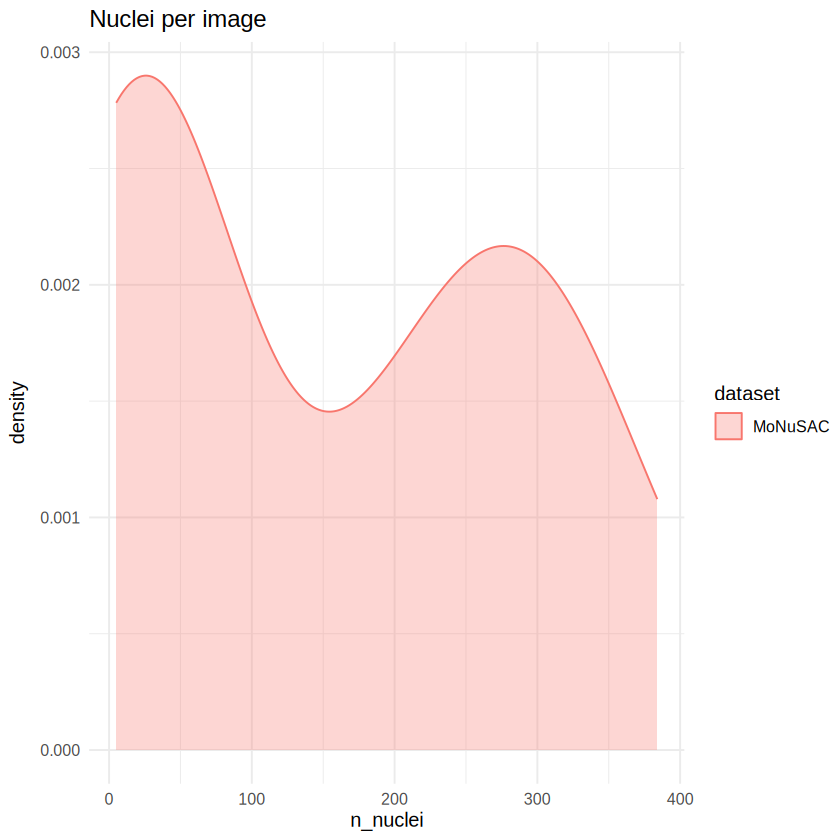

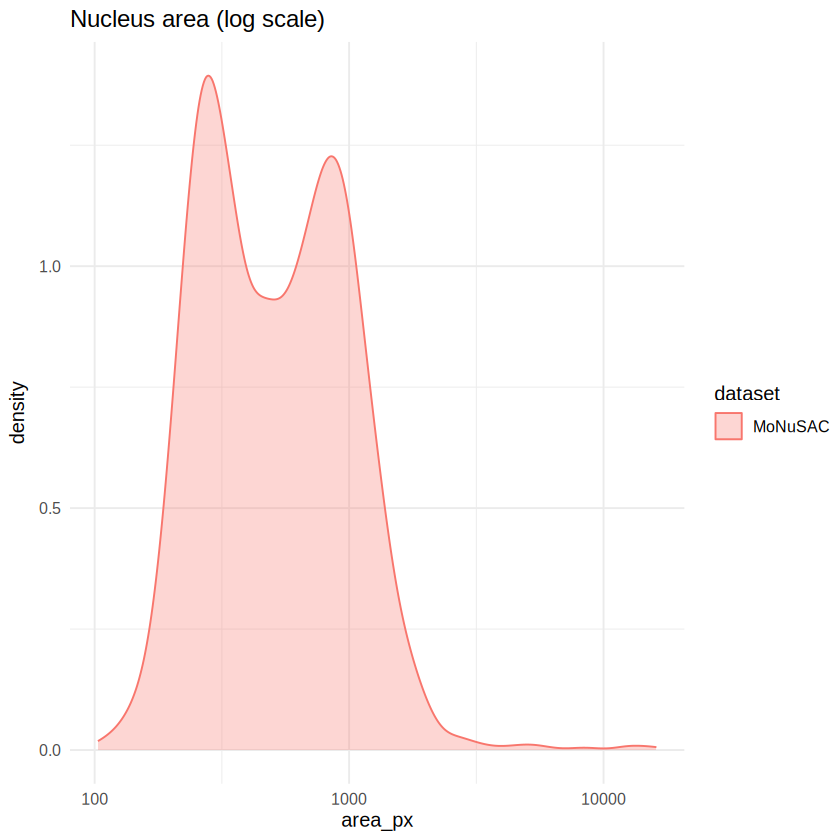

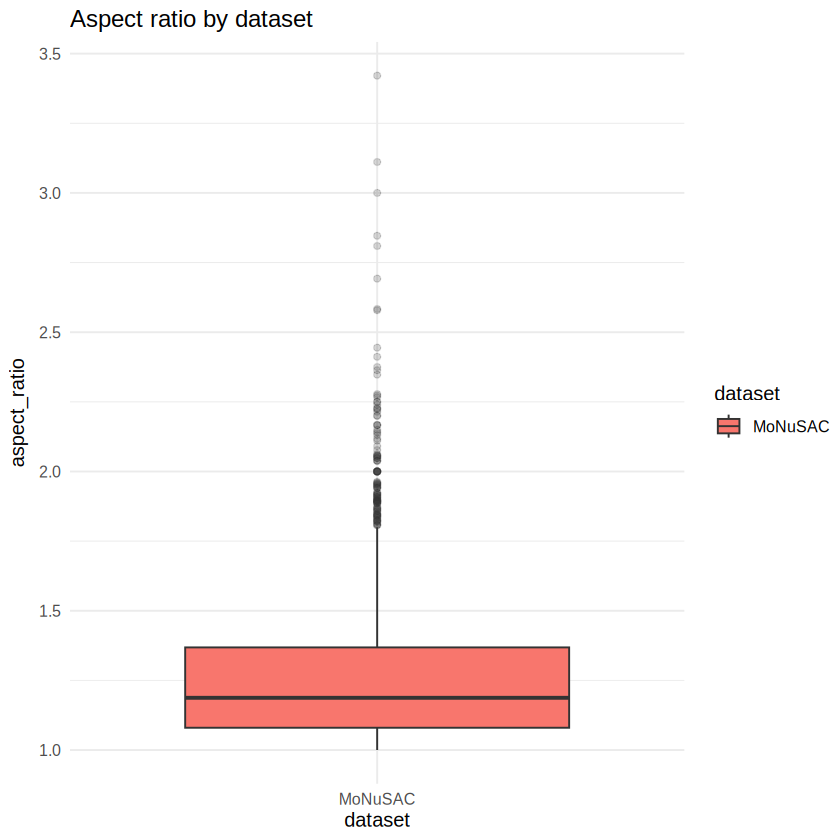

# A tibble: 1 × 5
  dataset n_images total_nuclei mean_nuclei_per_image mean_nucleus_area_px
  <chr>      <int>        <int>                 <dbl>                <dbl>
1 MoNuSAC       20         2978                  149.                 654.


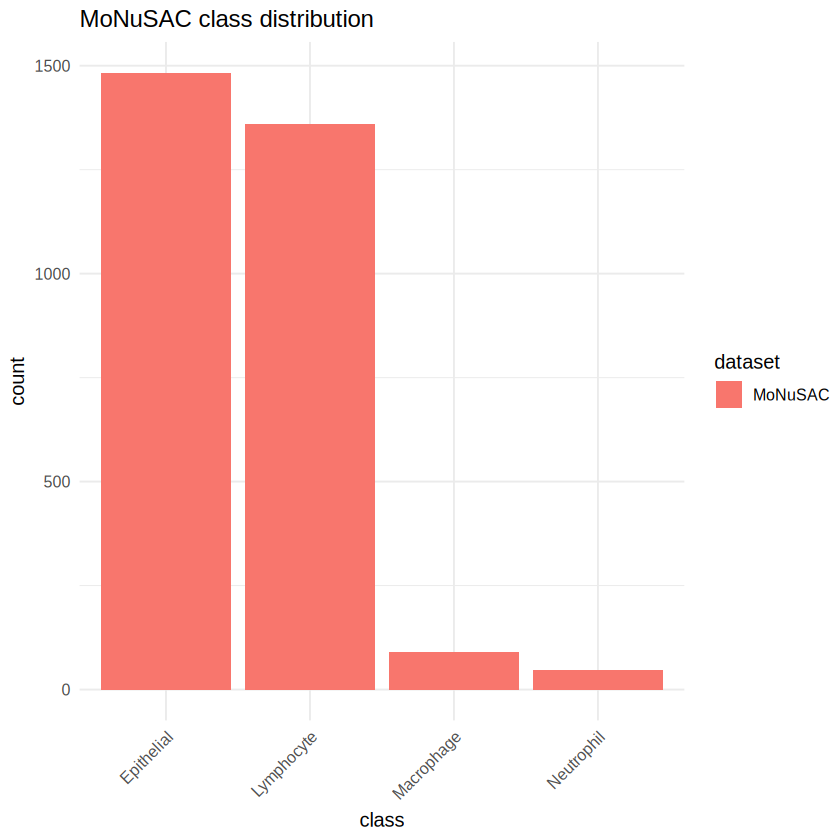

In [13]:
image_level_all   <- map_dfr(results, "image_level")
nucleus_level_all <- map_dfr(results, "nucleus_level")

theme_set(theme_minimal(base_size = 12))

ggplot(image_level_all, aes(n_nuclei, fill = dataset, color = dataset)) +
  geom_density(alpha = 0.3) + labs(title = "Nuclei per image")

ggplot(nucleus_level_all, aes(area_px, fill = dataset, color = dataset)) +
  geom_density(alpha = 0.3) + scale_x_log10() + labs(title = "Nucleus area (log scale)")

ggplot(nucleus_level_all, aes(dataset, aspect_ratio, fill = dataset)) +
  geom_boxplot(outlier.alpha = 0.2) + labs(title = "Aspect ratio by dataset")

nucleus_level_all %>% filter(!is.na(class)) %>%
  ggplot(aes(class, fill = dataset)) + geom_bar() +
  labs(title = "MoNuSAC class distribution") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

summary_tbl <- image_level_all %>% group_by(dataset) %>%
  summarise(n_images = n(), total_nuclei = sum(n_nuclei),
            mean_nuclei_per_image = round(mean(n_nuclei), 1), .groups = "drop") %>%
  left_join(nucleus_level_all %>% group_by(dataset) %>%
              summarise(mean_nucleus_area_px = round(mean(area_px), 1), .groups = "drop"),
            by = "dataset")

print(summary_tbl)